# **IRWA Final Project**

Authors: Carla Núñez u214970  /  Julia Pérez u214026  /  Jan Prats u213927

GitHub URL: https://github.com/Januto30/SearchEngine-IRWA_2025


In [1]:
# --- Install required dependencies ---
!pip install gensim tabulate wordcloud
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.2 MB/s eta 0:00:00


## **Part 0 -  Text Processing and Exploratory Data Analysis**

### Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#jan
#docs_path_json = '/content/drive/MyDrive/Web/IRWA_project_part_3/data/fashion_products_dataset.json'

#julia
docs_path_json = '/content/drive/MyDrive/4t/Web/IRWA_project_part_3/data/fashion_products_dataset.json'

#carla
#docs_path_json = '/content/drive/MyDrive/data/fashion_products_dataset.json'

Mounted at /content/drive


In [3]:
#Standard library imports
import json
import math
import re
import string
import datetime
from array import array
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from wordcloud import WordCloud
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download("punkt_tab")

#NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

#Download NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
with open(docs_path_json, 'r', encoding='utf-8') as f:
    json_data_products = json.load(f)

# Convert JSON list of dicts into DataFrame
df_products = pd.DataFrame(json_data_products)

### Preprocessing function

In [5]:
def build_terms(line):
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words("english"))      #Stop words

    line= line.lower()                                #Transform in lowercase
    line= re.sub(r'[^a-z0-9\s]', ' ', line)           #Remove non‑alphanumeric characters (removing punctuation marks, keep spaces)
    line= re.sub(r'\s+', ' ', line).strip()           #Collapse multiple spaces into a single space
    line= line.split()                                #Tokenize the text to get a list of terms
    line=[x for x in line if x not in stop_words]     #Eliminate the stopwords
    line=[stemmer.stem(word) for word in line]        #Perform stemming (teacher --> teach)

    return line

#Apply preprocessing to title and description
df_products['title_clean'] = df_products['title'].apply(build_terms)
df_products['description_clean'] = df_products['description'].apply(build_terms)

#Combine product_details into a single text field
def combine_product_details(details_list):
    if isinstance(details_list, list):
        return " ".join([str(list(d.values())[0]) for d in details_list])
    return ""

df_products['product_details_text'] = df_products['product_details'].apply(combine_product_details)

### Preprocessing for example

In [6]:
preprocessed_products = []

for prod in json_data_products:
    #Get the text fields (if missing, use empty string)
    title_raw = prod.get('title', '')
    descr_raw = prod.get('description', '')

    #Apply preprocessing pipeline
    title_tokens = build_terms(title_raw)
    descr_tokens = build_terms(descr_raw)

    #Keep all original fields along with the processed tokens
    prod_processed = {
        **prod,  # conservar tots els camps originals
        'title_tokens': title_tokens,
        'description_tokens': descr_tokens
    }
    preprocessed_products.append(prod_processed)

#Show the first product before and after preprocessing
first_raw = json_data_products[0]
first_proc = preprocessed_products[0]

print("=== Original Product ===")
print(f"Title      : {first_raw.get('title', 'N/A')}")
print(f"Description: {first_raw.get('description', 'N/A')}")

print("\n=== After Preprocessing ===")
print(f"Title Tokens      : {first_proc['title_tokens']}")
print(f"Description Tokens: {first_proc['description_tokens']}")

=== Original Product ===
Title      : Solid Women Multicolor Track Pants
Description: Yorker trackpants made from 100% rich combed cotton giving it a rich look.Designed for Comfort,Skin friendly fabric,itch-free waistband & great for all year round use Proudly made in India

=== After Preprocessing ===
Title Tokens      : ['solid', 'women', 'multicolor', 'track', 'pant']
Description Tokens: ['yorker', 'trackpant', 'made', '100', 'rich', 'comb', 'cotton', 'give', 'rich', 'look', 'design', 'comfort', 'skin', 'friendli', 'fabric', 'itch', 'free', 'waistband', 'great', 'year', 'round', 'use', 'proudli', 'made', 'india']


### Exploratory data analysis

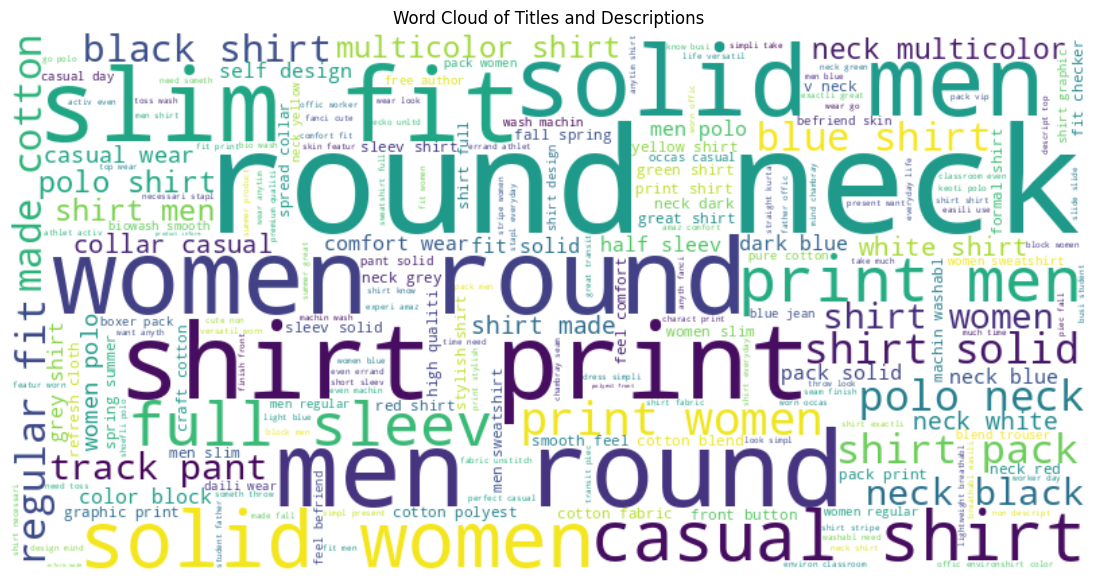

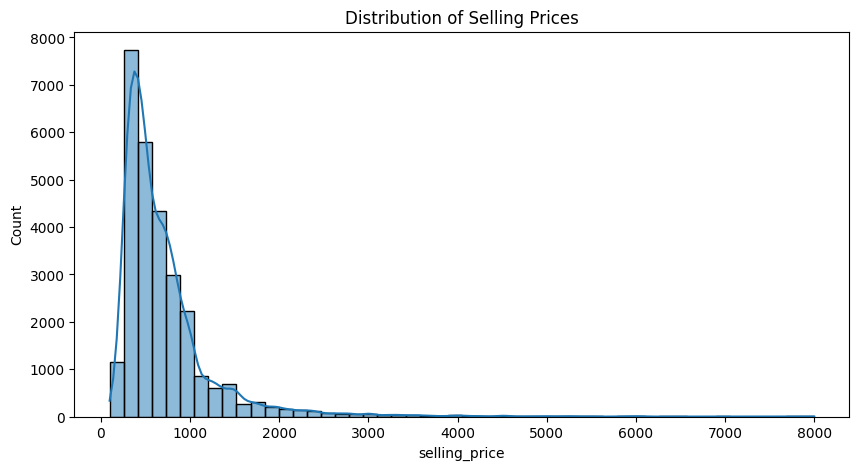

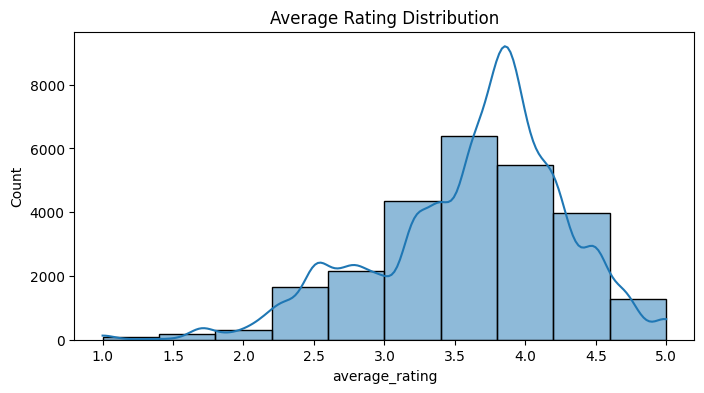

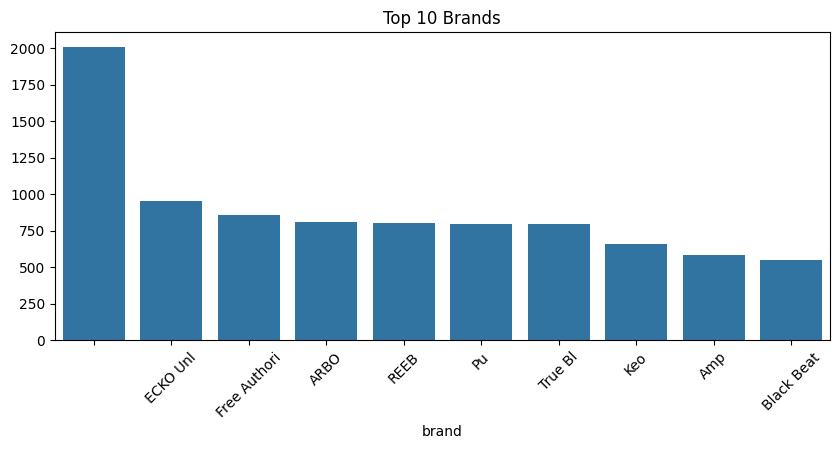

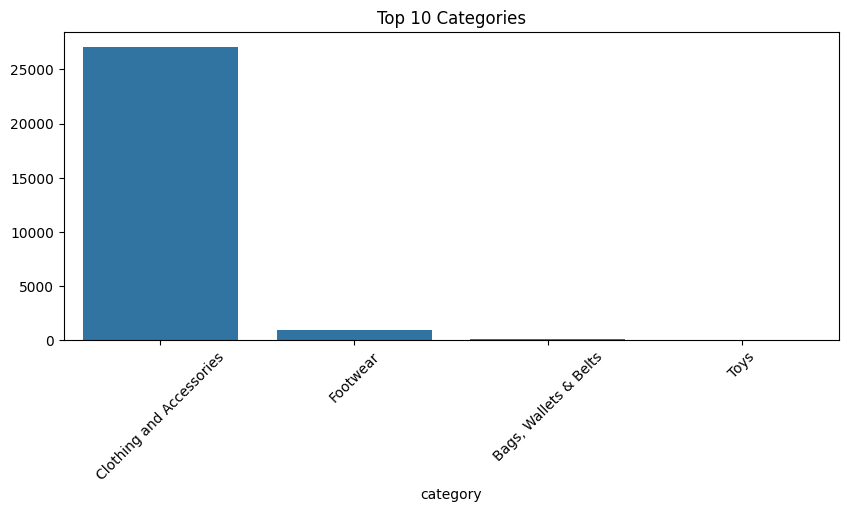

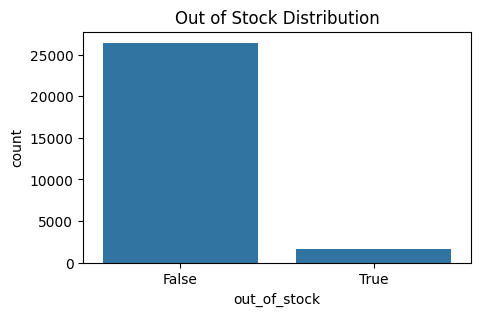

In [7]:
#Word Cloud
text_combined = " ".join([" ".join(x) for x in df_products['title_clean']] +
                         [" ".join(x) for x in df_products['description_clean']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Titles and Descriptions")
plt.show()

#Distribution of prices
df_products['selling_price'] = pd.to_numeric(df_products['selling_price'].str.replace(',', ''), errors='coerce')
df_products['actual_price'] = pd.to_numeric(df_products['actual_price'].str.replace(',', ''), errors='coerce')

plt.figure(figsize=(10,5))
sns.histplot(df_products['selling_price'].dropna(), bins=50, kde=True)
plt.title("Distribution of Selling Prices")
plt.show()

#Average rating distribution
df_products['average_rating'] = pd.to_numeric(df_products['average_rating'], errors='coerce')

plt.figure(figsize=(8,4))
sns.histplot(df_products['average_rating'].dropna(), bins=10, kde=True)
plt.title("Average Rating Distribution")
plt.show()

#Top brands and categories
top_brands = df_products['brand'].value_counts().head(10)
top_categories = df_products['category'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 10 Brands")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top 10 Categories")
plt.xticks(rotation=45)
plt.show()

#Out of stock distribution
plt.figure(figsize=(5,3))
sns.countplot(x='out_of_stock', data=df_products)
plt.title("Out of Stock Distribution")
plt.show()

preprocessed_cols = ['pid', 'title_clean', 'description_clean', 'brand', 'category',
                     'sub_category', 'product_details_text', 'seller', 'out_of_stock',
                     'selling_price', 'discount', 'actual_price', 'average_rating', 'url']

df_products[preprocessed_cols].to_csv("preprocessed_fashion_products.csv", index=False)

## **Part 1 -  Indexing**

### Build inverted index and TF-IDF data structures


In [8]:
def create_index_tfidf_from_products(df_products):
    """
    Create inverted index, tf, df, and idf structures for product dataset.
    """
    index = defaultdict(list)
    tf = defaultdict(list)  # term frequencies of terms in documents
    df_counts = defaultdict(int)  # document frequencies of terms
    idf = defaultdict(float)
    doc_titles = {}

    # Combine all preprocessed text fields for indexing
    documents = {}
    for idx, row in df_products.iterrows():
        details = row['product_details_text'] if isinstance(row['product_details_text'], str) else ""
        combined_text = " ".join([
            " ".join(row['title_clean']),
            " ".join(row['description_clean']),
            details
        ])
        documents[idx] = combined_text
        # si el DataFrame no té la columna 'title', usem title_clean
        doc_titles[idx] = row['title'] if 'title' in row else " ".join(row['title_clean'])

    num_documents = len(documents)

    # build index
    for doc_id, text in documents.items():
        terms = build_terms(text)
        current_page_index = {}

        for pos, term in enumerate(terms):
            if term in current_page_index:
                current_page_index[term][1].append(pos)
            else:
                current_page_index[term] = [doc_id, array('I', [pos])]

        # Compute normalization factor for TF
        norm = math.sqrt(sum(len(posting[1]) ** 2 for posting in current_page_index.values()))

        # Compute TF and DF
        for term, posting in current_page_index.items():
            tf[term].append(round(len(posting[1]) / norm, 4))
            df_counts[term] += 1
            index[term].append(posting)

    # compute IDF
    for term, df_val in df_counts.items():
        idf[term] = round(np.log((1 + num_documents) / (1 + df_val)), 4)

    return index, tf, df_counts, idf, doc_titles


### Provide ranking-based results (Conjunctive AND queries)

In [9]:
# Afegim un diccionari que relacioni cada doc_id amb el seu pid
pid_map = df_products['pid'].to_dict()  # {row_index: pid}

def search_query(query, index, tf, idf, doc_titles, pid_map):
    """
    Execute a conjunctive AND query using TF-IDF ranking.
    Returns list of (pid, score)
    """
    query = build_terms(query)
    if not query:
        return []

    # Get list of document IDs per term
    doc_sets = []
    for term in query:
        if term in index:
            doc_ids = [posting[0] for posting in index[term]]
            doc_sets.append(set(doc_ids))
        else:
            return []

    # Intersect (AND) all document sets
    matching_docs = set.intersection(*doc_sets)
    if not matching_docs:
        return []

    # Compute TF-IDF ranking
    scores = defaultdict(float)
    for term in query:
        if term in index:
            for i, posting in enumerate(index[term]):
                doc_id = posting[0]
                if doc_id in matching_docs:
                    scores[doc_id] += tf[term][i] * idf[term]

    # Rank in descending order
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [(pid_map[doc_id], score) for doc_id, score in ranked]  # return pid, not title


### Propose test queries and show ranked results

In [10]:
test_queries = [
    "hardware components",
    "round neck blue shirt",
    "casual shirt men",
    "women slim fit",
    "polo ice cream"
]

In [11]:
# Build the index
index, tf, df_counts, idf, doc_titles = create_index_tfidf_from_products(df_products)

for q in test_queries:
    results = search_query(q, index, tf, idf, doc_titles, pid_map)
    print(f"\nQuery: '{q}'")

    if not results:  # check if list is empty
        print("No matching products found in the dataset for this query.")
        continue

    for pid, score in results[:10]:
        title = df_products.loc[df_products['pid'] == pid, 'title'].values[0]
        print(f"  {pid} | {title[:55]}...  (score={score:.4f})")



Query: 'hardware components'
No matching products found in the dataset for this query.

Query: 'round neck blue shirt'
  TSHFWSAQGM4NDRZV | Solid Men Round Neck Blue T-Shirt...  (score=1.4428)
  TSHFVW7FXGAPEXFE | Typography Men Round Neck Blue T-Shirt...  (score=1.4157)
  TSHFYRYBHWBHF4WU | Solid Women Round Neck Blue T-Shirt  (Pack of 4)...  (score=1.4057)
  TSHFVTWHZKS6MWAE | Typography Women Round Neck Blue T-Shirt...  (score=1.3970)
  TSHFKWPTYYWSTSZJ | Printed Women Round Neck Dark Blue, Blue T-Shirt  (Pack...  (score=1.3829)
  TSHFEY8VRGCMRSGG | Typography Women Round Neck Blue T-Shirt...  (score=1.3777)
  TSHFVK5QPHBCKXU2 | Textured Men Round Neck Blue T-Shirt...  (score=1.3726)
  TSHFHBQN5Y8EMDWZ | Solid Women Round Neck Blue T-Shirt...  (score=1.3711)
  TSHFHHQFEQT56GZP | Color Block Men Round Neck Blue T-Shirt...  (score=1.3680)
  TSHFEY8WPK7F3TG5 | Color Block Men Round Neck Blue T-Shirt...  (score=1.3642)

Query: 'casual shirt men'
  SHTFACSAS6WTFZ5G | Men Slim Fit Solid 

## **Part 2 -  Evaluation**

### Implement evaluation metrics to assess the effectiveness of the retrieval solutions

In [12]:
# P@K
def precision_at_k(relevance_list, k):
    relevance = np.array(relevance_list)[:k]
    return np.mean(relevance) if len(relevance) > 0 else 0.0

# R@K
def recall_at_k(relevance_list, total_relevant, k):
    relevance = np.array(relevance_list)[:k]
    return np.sum(relevance) / total_relevant if total_relevant > 0 else 0.0

# avg P@K
def average_precision_at_k(relevance_list, k):
    relevance = np.array(relevance_list)[:k]
    precisions = [precision_at_k(relevance_list, i + 1)
                  for i in range(len(relevance)) if relevance[i]]
    return np.mean(precisions) if len(precisions) > 0 else 0.0

# F1@Score
def f1_at_k(precision, recall):
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# MAP
def mean_average_precision(all_relevance_lists, k):
    ap_scores = [average_precision_at_k(rel, k) for rel in all_relevance_lists]
    return np.mean(ap_scores)

# RR
def reciprocal_rank(relevance_list):
    for i, rel in enumerate(relevance_list):
        if rel == 1:
            return 1 / (i + 1)
    return 0.0

# MRR
def mean_reciprocal_rank(all_relevance_lists):
    return np.mean([reciprocal_rank(rel) for rel in all_relevance_lists])

# NDCG
def ndcg_at_k(relevance_list, k):
    rel = np.array(relevance_list)[:k]
    dcg = np.sum(rel / np.log2(np.arange(2, len(rel) + 2)))
    ideal_rel = np.sort(rel)[::-1]
    idcg = np.sum(ideal_rel / np.log2(np.arange(2, len(ideal_rel) + 2)))
    return dcg / idcg if idcg > 0 else 0.0


# function to evaluate a query
def evaluate_query(query_id, results, labels_df, k):
    query_labels = labels_df[labels_df['query_id'] == query_id]
    relevance = [
        int(query_labels[query_labels['pid'] == pid]['labels'].values[0])
        if pid in list(query_labels['pid']) else 0
        for pid, _ in results[:k]
    ]
    total_relevant = query_labels['labels'].sum()

    P = precision_at_k(relevance, k)
    R = recall_at_k(relevance, total_relevant, k)
    AP = average_precision_at_k(relevance, k)
    F1 = f1_at_k(P, R)
    RR = reciprocal_rank(relevance)
    NDCG = ndcg_at_k(relevance, k)

    # Construir diccionario de métricas
    metrics = {
        'P@K': round(P, 3),
        'R@K': round(R, 3),
        'AP@K': round(AP, 3),
        'F1@K': round(F1, 3),
        'RR': round(RR, 3),
        'NDCG': round(NDCG, 3)
    }

    # Imprimir con formato bonito
    print(f"\nQuery {query_id} metrics:")
    print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

    return metrics

### Apply the evaluation metrics implemented to the search results and relevance judgments.

In [14]:
#julia
labels_path = '/content/drive/MyDrive/4t/Web/IRWA_project_part_3/data/validation_labels.csv'

#carla
#labels_path = '/content/drive/MyDrive/data/validation_labels.csv'

#jan
#labels_path = '/content/drive/MyDrive/Web/IRWA_project_part_3/data/validation_labels.csv'

labels_df = pd.read_csv(labels_path)

q1_text = "women full sleeve sweatshirt cotton"
q2_text = "men slim jeans blue"

results_q1 = search_query(q1_text, index, tf, idf, doc_titles, pid_map)
results_q2 = search_query(q2_text, index, tf, idf, doc_titles, pid_map)

eval_q1 = evaluate_query(1, results_q1, labels_df, k=10)
eval_q2 = evaluate_query(2, results_q2, labels_df, k=10)

# Overall metrics
all_relevance_lists = []
for qid, results in zip([1, 2], [results_q1, results_q2]):
    query_labels = labels_df[labels_df['query_id'] == qid]
    rel_list = [
        int(query_labels[query_labels['pid'] == pid]['labels'].values[0])
        if pid in list(query_labels['pid']) else 0
        for pid, _ in results[:10]
    ]
    all_relevance_lists.append(rel_list)

MAP_score = mean_average_precision(all_relevance_lists, k=10)
MRR_score = mean_reciprocal_rank(all_relevance_lists)

print(f"\nOverall MAP: {MAP_score:.3f}")
print(f"Overall MRR: {MRR_score:.3f}")


Query 1 metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |       0 |
+----------+---------+
| R@K      |       0 |
+----------+---------+
| AP@K     |       0 |
+----------+---------+
| F1@K     |       0 |
+----------+---------+
| RR       |       0 |
+----------+---------+
| NDCG     |       0 |
+----------+---------+

Query 2 metrics:
+----------+---------+
| Metric   |   Value |
+==========+=========+
| P@K      |   0.1   |
+----------+---------+
| R@K      |   0.1   |
+----------+---------+
| AP@K     |   0.5   |
+----------+---------+
| F1@K     |   0.1   |
+----------+---------+
| RR       |   0.5   |
+----------+---------+
| NDCG     |   0.631 |
+----------+---------+

Overall MAP: 0.250
Overall MRR: 0.250


### Establishing the ground truth for each document and query

In [55]:
# test_queries defined in Section 2.3
"""
test_queries = [
    "hardware components",
    "round neck blue shirt",
    "casual shirt men",
    "women slim fit",
    "polo ice cream"
]
"""
query_ids = [1, 2, 3, 4, 5]

# Create inverse mapping PID → document index (to fetch titles correctly)
pid_to_docid = {v: k for k, v in pid_map.items()}

# Dictionary to store results
results_dict = {}

# Dictionary to store real relevance
ground_truth_custom = {}

# Display top search results per query in test_queries
print("=== Top search results per query ===")

for qid, query in zip(query_ids, test_queries):
  results = search_query(query, index, tf, idf, doc_titles, pid_map)  # return (pid_map[doc_id], score) for doc_id, score in ranked
  results_dict[qid] = results

  print(f"\nQuery {qid}: '{query}'")

  if not results:  #list of results empty
      print("No matching products found in the dataset for this query.\n")
      ground_truth_custom[qid] = {}
      continue

  rows = []
  for i, (pid, score) in enumerate(results[:5]):
      title = doc_titles.get(pid_to_docid.get(pid, -1), "Unknown Title")
      short_title = title[:70] + ("..." if len(title) > 70 else "")
      rows.append([i + 1, pid, short_title, f"{score:.4f}"])

  print(tabulate(rows, headers=["Rank", "Product ID", "Title", "Score"], tablefmt="grid"))

  # assign Binary Relevance Judgments
  # Dictionary to save relevant documents for the expert
  pid_relevance = {}
  for i, (pid, score) in enumerate(results[:5]):
      while True:
        # 1 = relevant, 0 = not relevant (manually)
        user_input = input(f"Is Document ranked {i+1} relevant to query '{query}'? (1=Yes, 0=No): ").strip()
        if user_input in ["0", "1"]:
          relevance = int(user_input)
          pid_relevance[pid] = relevance
          break  # exit the loop once valid input is given
        else:
          print("Invalid input! Please enter 1 for relevant or 0 for not relevant.")


  ground_truth_custom[qid] = pid_relevance


print("\n=== Evaluation metrics ===")

query_evaluations = {}
all_relevance_lists = []

for qid, qtext in zip(query_ids, test_queries):
    results = results_dict[qid]

    if not results:
        print(f"\nQuery {qid} ('{qtext}') has no retrieved documents.")
        continue

    relevant_pids = [pid for pid, label in ground_truth_custom[qid].items() if label == 1]
    relevance_list = [1 if pid in relevant_pids else 0 for pid, _ in results[:5]]
    all_relevance_lists.append(relevance_list)

    total_relevant = sum(relevance_list)
    P = precision_at_k(relevance_list, k=5)
    R = recall_at_k(relevance_list, total_relevant, k=5)
    AP = average_precision_at_k(relevance_list, k=5)
    F1 = f1_at_k(P, R)
    RR = reciprocal_rank(relevance_list)
    NDCG = ndcg_at_k(relevance_list, k=5)

    metrics = {
        'P@K': round(P, 3),
        'R@K': round(R, 3),
        'AP@K': round(AP, 3),
        'F1@K': round(F1, 3),
        'RR': round(RR, 3),
        'NDCG': round(NDCG, 3)
    }

    query_evaluations[qid] = metrics
    print(f"\nQuery {qid} ('{qtext}') metrics:")
    print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

# Overall Evaluation

MAP_custom = mean_average_precision(all_relevance_lists, k=5)
MRR_custom = mean_reciprocal_rank(all_relevance_lists)

print("\nOverall evaluation results:")
print(f"Mean Average Precision (MAP):  {MAP_custom:.3f}")
print(f"Mean Reciprocal Rank (MRR):    {MRR_custom:.3f}")

=== Top search results per query ===

Query 1: 'Slim Men Dark Blue Jeans'
+--------+------------------+--------------------------+---------+
|   Rank | Product ID       | Title                    |   Score |
+========+==================+==========================+=========+
|      1 | JEAEVJGUSXRNSHRY | Slim Men Dark Blue Jeans |  2.9718 |
+--------+------------------+--------------------------+---------+
|      2 | JEAFJV3HMBB9YA7G | Slim Men Dark Blue Jeans |  2.8476 |
+--------+------------------+--------------------------+---------+
|      3 | JEAFJM2P2FQQJF3C | Slim Men Dark Blue Jeans |  2.758  |
+--------+------------------+--------------------------+---------+
|      4 | JEAFEKQZNAWHW8PT | Slim Men Dark Blue Jeans |  2.7541 |
+--------+------------------+--------------------------+---------+
|      5 | JEAF2QF6HNZHDXVX | Slim Men Dark Blue Jeans |  2.6308 |
+--------+------------------+--------------------------+---------+
Is Document ranked 1 relevant to query 'Slim Men Dark B

In [36]:
def evaluate_results(ground_truth, results_dict, test_queries, query_ids):

    print("\n=== Evaluation metrics ===")

    query_evaluations = {}
    all_relevance_lists = []

    for qid, qtext in zip(query_ids, test_queries):
        results = results_dict.get(qid, [])

        if not results:
            print(f"\nQuery {qid} ('{qtext}') has no retrieved documents.")
            continue

        relevant_pids = [pid for pid, label in ground_truth[qid].items() if label == 1]
        relevance_list = [1 if pid in relevant_pids else 0 for pid, _ in results[:5]]
        all_relevance_lists.append(relevance_list)

        total_relevant = sum(relevance_list)
        P = precision_at_k(relevance_list, k=5)
        R = recall_at_k(relevance_list, total_relevant, k=5)
        AP = average_precision_at_k(relevance_list, k=5)
        F1 = f1_at_k(P, R)
        RR = reciprocal_rank(relevance_list)
        NDCG = ndcg_at_k(relevance_list, k=5)

        metrics = {
            'P@K': round(P, 3),
            'R@K': round(R, 3),
            'AP@K': round(AP, 3),
            'F1@K': round(F1, 3),
            'RR': round(RR, 3),
            'NDCG': round(NDCG, 3)
        }

        query_evaluations[qid] = metrics

        print(f"\nQuery {qid} ('{qtext}') metrics:")
        print(tabulate(metrics.items(), headers=["Metric", "Value"], tablefmt="grid"))

    # Overall Evaluation
    MAP_custom = mean_average_precision(all_relevance_lists, k=5)
    MRR_custom = mean_reciprocal_rank(all_relevance_lists)

    print("\nOverall evaluation results:")
    print(f"Mean Average Precision (MAP):  {MAP_custom:.3f}")
    print(f"Mean Reciprocal Rank (MRR):    {MRR_custom:.3f}")

    return query_evaluations, MAP_custom, MRR_custom


## **Part 3 - Ranking & Filtering**

### 3.1 Ranking functions

#### BM25

In [37]:
#Recompute doc lengths & avgdl just in case (safe idempotent)
def compute_doc_lengths_and_avgdl(index, df_products):
    doc_len = defaultdict(int)
    for term, postings in index.items():
        for posting in postings:
            doc_id = posting[0]
            freq = len(posting[1])
            doc_len[doc_id] += freq
    #ensure all docs present
    for doc_id in df_products.index:
        if doc_id not in doc_len:
            doc_len[doc_id] = 0
    avgdl = np.mean(list(doc_len.values())) if len(doc_len) > 0 else 0.0
    return dict(doc_len), float(avgdl)

def compute_bm25_idf(N, df_counts):
    idf_bm25 = {}
    for term, df_val in df_counts.items():
        #Robertson-Sparck Jones IDF (can be negative if df>N/2; keep value)
        #add tiny epsilon inside log to avoid log(0)
        idf_bm25[term] = math.log((N - df_val + 0.5) / (df_val + 0.5) + 1e-9)
    return idf_bm25

#compute / recompute
N = len(df_products)
doc_len, avgdl = compute_doc_lengths_and_avgdl(index, df_products)
idf_bm25 = compute_bm25_idf(N, df_counts)

In [38]:
def score_bm25_for_docs(query_terms, index, doc_set, idf_bm25, doc_len, avgdl, k1=1.5, b=0.75):
    scores = defaultdict(float)
    if avgdl <= 0:
        avgdl = 1.0  # avoid division by zero

    for term in query_terms:
        if term not in index:
            continue
        postings = index[term]
        idf = idf_bm25.get(term, 0.0)
        for posting in postings:
            doc_id = posting[0]
            if doc_id not in doc_set:
                continue
            freq = len(posting[1])  # raw term frequency in doc
            dl = doc_len.get(doc_id, 0.0)
            denom = freq + k1 * (1 - b + b * (dl / (avgdl + 1e-9)))
            # BM25 term contribution
            term_score = idf * ((freq * (k1 + 1.0)) / (denom + 1e-9))
            scores[doc_id] += term_score
    return scores

In [39]:
def bm25_search(query, index, tf, idf, doc_titles, pid_map, top_k=100):
    query_terms = build_terms(query)
    if not query_terms:
        return []
    # conjunctive AND semantics
    doc_sets = []
    for term in query_terms:
        if term in index:
            doc_sets.append(set([posting[0] for posting in index[term]]))
        else:
            return []
    matching_docs = set.intersection(*doc_sets)
    if not matching_docs:
        return []
    raw_scores = score_bm25_for_docs(query_terms, index, matching_docs, idf_bm25, doc_len, avgdl)
    ranked = sorted(raw_scores.items(), key=lambda x: x[1], reverse=True)
    return [(pid_map[doc_id], score) for doc_id, score in ranked[:top_k]]


####  TF-IDF + cosine similarity

In [40]:
def score_tfidf_cosine_for_docs(query_terms, index, tf, idf, doc_set):
    scores = defaultdict(float)
    for term in query_terms:
        if term not in index:
            continue
        postings = index[term]      # list of (doc_id, freq, etc.)
        tf_list = tf.get(term, [])  # TF values for this term
        for i, posting in enumerate(postings):
            doc_id = posting[0]
            if doc_id not in doc_set:  # only score docs in the allowed set
                continue
            tf_val = tf_list[i] if i < len(tf_list) else 0.0
            scores[doc_id] += tf_val * idf.get(term, 0.0)
    return scores

#### Custom scoring

In [41]:
def compute_feature_boost_for_doc(doc_id, df_products, max_price=None, max_discount=None):
    row = df_products.loc[doc_id] # obtain product row

    #rating
    rating = 0.0
    try:
        #if the value is NOT NaN assign to rating as a float and if it IS NaN assign 0.0 to rating
        rating = float(row.get('average_rating', 0.0)) if not pd.isna(row.get('average_rating', np.nan)) else 0.0
    except:
        rating = 0.0
    #normalize between 0 - 1 dividing by 5
    rating_norm = min(max(rating / 5.0, 0.0), 1.0)

    #in-stock
    out_of_stock = row.get('out_of_stock', False)
    if isinstance(out_of_stock, str):
        is_out = out_of_stock.strip().lower() in ('true','1','yes')
    else:
        is_out = bool(out_of_stock)
    in_stock_flag = 1.0 if not is_out else 0.0

    #price
    price = 0.0
    try:
        price = float(row.get('selling_price', 0.0)) if not pd.isna(row.get('selling_price', np.nan)) else 0.0
    except:
        price = 0.0
    if max_price is None or max_price <= 0:
        #take the max price defined in the DataFrame to normalize
        max_price = df_products['selling_price'].dropna().max() if 'selling_price' in df_products.columns else 1.0
        if pd.isna(max_price) or max_price <= 0:
            max_price = 1.0  # for not divinding by 0
    price_norm = price / max_price  # 0 -> cheap   1 -> expensive

    #discount
    discount = 0.0
    try:
        #if discount stored like "69% off", try to extract number
        disc_raw = row.get('discount', 0.0)
        if isinstance(disc_raw, str):
            import re
            m = re.search(r'(\d+)', disc_raw)
            discount = float(m.group(1)) if m else 0.0
        else:
            discount = float(disc_raw)
    except:
        discount = 0.0
    #normalize between 0 - 1 dividing by 100
    discount_norm = min(max(discount / 100.0, 0.0), 1.0)

    #definition of weights
    w_rating = 0.35; w_instock = 0.25; w_price = 0.25; w_discount = 0.15
    #higher rating -> higher boost
    #in stock -> higher boost
    #low price (1 - price_norm) -> higher boost
    #high discount -> higher boost
    boost = 1.0 + (w_rating * rating_norm) + (w_instock * in_stock_flag) + (w_price * (1 - price_norm)) + (w_discount * discount_norm)
    boost = max(0.1, min(boost, 3.0))
    return boost

In [42]:
def score_custom_for_docs(query_terms, index, doc_set, idf_bm25, doc_len, avgdl, df_products):
    bm25_scores = score_bm25_for_docs(query_terms, index, doc_set, idf_bm25, doc_len, avgdl)
    max_price = df_products['selling_price'].dropna().max() if 'selling_price' in df_products.columns else None
    max_discount = None
    if 'discount' in df_products.columns:
        #extract numeric discount where possible
        def parse_disc(x):
            try:
                if isinstance(x, str):
                    m = re.search(r'(\d+)', x)
                    return float(m.group(1)) if m else 0.0
                else:
                    return float(x)
            except:
                return 0.0
        max_discount = df_products['discount'].dropna().map(parse_disc).max()
    scores = {}
    for doc_id, base in bm25_scores.items():
        boost = compute_feature_boost_for_doc(doc_id, df_products, max_price=max_price, max_discount=max_discount)
        scores[doc_id] = base * boost
    return scores

In [43]:
def myscore_search(query, index, tf, idf, doc_titles, pid_map, top_k=100):
    query_terms = build_terms(query)   # tokenize and normalize query
    if not query_terms:
        return []
    doc_sets = []
    for term in query_terms:
        if term in index:
            doc_sets.append(set([posting[0] for posting in index[term]]))
        else:
            return []
    matching_docs = set.intersection(*doc_sets)
    if not matching_docs:
        return []
    raw_scores = score_custom_for_docs(query_terms, index, matching_docs, idf_bm25, doc_len, avgdl, df_products) # compute scores for matched docs
    ranked = sorted(raw_scores.items(), key=lambda x: x[1], reverse=True)
    return [(pid_map[doc_id], score) for doc_id, score in ranked[:top_k]]

#### Execution function + example

In [44]:
def print_results(all_results, df_products, top_k=10):
    for res in all_results:
        print(f"\n=== Query: '{res['query']}' ===")

        for method in ['tfidf', 'bm25', 'our']:
            print(f"\n{method.upper()} Top Documents:")
            scores = res[method]

            if not scores:
                print("  No results found.")
                continue

            for rank, (doc_id, score) in enumerate(scores[:top_k], start=1):
                #Round score nicely for display
                if isinstance(score, (np.float64, float)):
                    score = round(float(score), 4)

                #Look up title from df_products
                title = df_products.loc[df_products['pid'] == doc_id, 'title'].values[0]

                print(f"  {rank:>2}. {doc_id} | {title[:55]}... | score: {score}")

        print("\n" + "-"*50)

In [45]:
#we change the test_queries of previous parts due to the feedback received for implementing evaluation
test_queries = [
    "Slim Men Dark Blue Jeans",
    "Tapered Fit Blue Jeans",
    "Super Skinny Women Blue Jeans",
    "Women Blue Jeans",
    "Slim Men Blue Jeans"
]

top_k = 10
all_results = []

for q in test_queries:
    tfidf_results = search_query(q, index, tf, idf, doc_titles, pid_map)[:top_k]
    bm25_results = bm25_search(q, index, tf, idf, doc_titles, pid_map, top_k=top_k)
    custom_results = myscore_search(q, index, tf, idf, doc_titles, pid_map, top_k=top_k)

    all_results.append({
        'query': q,
        'tfidf': tfidf_results,
        'bm25': bm25_results,
        'our': custom_results
    })

print_results(all_results, df_products)


=== Query: 'Slim Men Dark Blue Jeans' ===

TFIDF Top Documents:
   1. JEAEVJGUSXRNSHRY | Slim Men Dark Blue Jeans... | score: 2.9718
   2. JEAFJV3HMBB9YA7G | Slim Men Dark Blue Jeans... | score: 2.8476
   3. JEAFJM2P2FQQJF3C | Slim Men Dark Blue Jeans... | score: 2.758
   4. JEAFEKQZNAWHW8PT | Slim Men Dark Blue Jeans... | score: 2.7541
   5. JEAF2QF6HNZHDXVX | Slim Men Dark Blue Jeans... | score: 2.6308
   6. JEAFVWFKEGHNT3HD | Slim Men Dark Blue Jeans... | score: 2.5388
   7. JEAFYGU2GXZZJTZF | Slim Men Dark Blue Jeans... | score: 2.4873
   8. JEAFVXG4GGZH9VFA | Slim Men Dark Blue Jeans... | score: 2.4558
   9. JEAFVXG4N29PCJWP | Slim Men Dark Blue Jeans... | score: 2.4558
  10. JEAEJYZ8KAGSABDQ | Slim Men Dark Blue Jeans... | score: 2.4076

BM25 Top Documents:
   1. JEAEVJGUSXRNSHRY | Slim Men Dark Blue Jeans... | score: 12.4443
   2. JEAFJM2P2FQQJF3C | Slim Men Dark Blue Jeans... | score: 11.9492
   3. JEAFJV3HMBB9YA7G | Slim Men Dark Blue Jeans... | score: 11.8858
   4. JEAFEKQZN

#### Evaluate rankings and results

In [46]:
def evaluate_all_results(all_results, labels_df, methods, top_k=10):
    method_metrics = defaultdict(list)

    #PID -> 1/0 relevance map
    pid_relevance_map = labels_df.set_index('pid')['labels'].to_dict()

    print("\n=== Per-Query Evaluation ===")

    for res in all_results:
        query_text = res["query"]
        print(f"\n--- Query: '{query_text}' ---")

        for method in methods:  #['tfidf', 'bm25', 'our'] or ['word2vec', 'doc2vec']
            results = res[method]

            #Extract PIDs and convert to binary relevance
            relevance = [int(pid_relevance_map.get(r[0], 0)) for r in results[:top_k]]

            total_relevant = sum(pid_relevance_map.values())  #total relevant docs in dataset

            P = precision_at_k(relevance, top_k)
            R = recall_at_k(relevance, total_relevant, top_k)

            method_metrics[method].append({'P@K': P, 'R@K': R})

            print(f"  {method.upper():<6} | Precision@{top_k}: {P:.3f} | Recall@{top_k}: {R:.3f}")

    # avgs
    avg_metrics = {}
    for method, metrics_list in method_metrics.items():
        avg_P = np.mean([m['P@K'] for m in metrics_list])
        avg_R = np.mean([m['R@K'] for m in metrics_list])
        avg_metrics[method] = {
            'Avg P@K': round(avg_P, 3),
            'Avg R@K': round(avg_R, 3)
        }

    print("\n=== Evaluation Summary (Average Metrics) ===")
    print(tabulate([(m, v['Avg P@K'], v['Avg R@K']) for m, v in avg_metrics.items()],
                   headers=["Method", "Avg P@K", "Avg R@K"], tablefmt="grid"))

    return avg_metrics

In [47]:
#Evaluate all ranking methods ignoring query_id
methods2evaluate = ['tfidf', 'bm25', 'our']
avg_metrics = evaluate_all_results(all_results, labels_df, methods2evaluate, top_k=10)


=== Per-Query Evaluation ===

--- Query: 'Slim Men Dark Blue Jeans' ---
  TFIDF  | Precision@10: 0.100 | Recall@10: 0.043
  BM25   | Precision@10: 0.100 | Recall@10: 0.043
  OUR    | Precision@10: 0.000 | Recall@10: 0.000

--- Query: 'Tapered Fit Blue Jeans' ---
  TFIDF  | Precision@10: 0.100 | Recall@10: 0.043
  BM25   | Precision@10: 0.100 | Recall@10: 0.043
  OUR    | Precision@10: 0.200 | Recall@10: 0.087

--- Query: 'Super Skinny Women Blue Jeans' ---
  TFIDF  | Precision@10: 0.200 | Recall@10: 0.087
  BM25   | Precision@10: 0.200 | Recall@10: 0.087
  OUR    | Precision@10: 0.200 | Recall@10: 0.087

--- Query: 'Women Blue Jeans' ---
  TFIDF  | Precision@10: 0.000 | Recall@10: 0.000
  BM25   | Precision@10: 0.100 | Recall@10: 0.043
  OUR    | Precision@10: 0.000 | Recall@10: 0.000

--- Query: 'Slim Men Blue Jeans' ---
  TFIDF  | Precision@10: 0.100 | Recall@10: 0.043
  BM25   | Precision@10: 0.100 | Recall@10: 0.043
  OUR    | Precision@10: 0.100 | Recall@10: 0.043

=== Evaluation

### 3.2 -  word2vec + cosine



#### functions

In [48]:
def train_word2vec(df_products, text_column="title", vector_size=100, window=5, min_count=1):
    corpus = [word_tokenize(str(text).lower()) for text in df_products[text_column]]  # tokenize each product title into lowercase word lists

    model = Word2Vec(
        sentences=corpus,  # training data
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4     # number of CPU threads
    )
    return model

In [49]:
def embed_text(text, model):
    words = word_tokenize(str(text).lower())
    vectors = []

    for w in words:
        if w in model.wv:  # check if word exists in vocabulary
            vectors.append(model.wv[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [50]:
def build_document_embeddings(df_products, model):
    embeddings = []
    for text in df_products["title"]:
        vec = embed_text(text, model) # compute embedding for the title
        embeddings.append(vec)  #store
    return np.vstack(embeddings)

In [51]:
def search_word2vec(query, df_products, doc_embeddings, model, top_k=20):

    #preprocess query
    query_tokens = build_terms(query)

    #AND semantics to the cleaned title
    mask = df_products['title_clean'].apply(
        lambda tokens: all(qt in tokens for qt in query_tokens)
    )

    df_filtered = df_products[mask]

    if df_filtered.empty:
        return []

    #vectorize query
    q_vec = embed_text(query, model).reshape(1, -1)

    #obtain embeddings filtered
    filtered_idx = df_filtered.index
    filtered_embeddings = doc_embeddings[filtered_idx]

    # compute vector similarity
    sims = cosine_similarity(q_vec, filtered_embeddings)[0]

    #sort top results
    sorted_idx = np.argsort(sims)[::-1][:top_k]

    results = []
    for i in sorted_idx:
        idx = filtered_idx[i]
        pid = df_products.iloc[idx]['pid']
        title = df_products.iloc[idx]['title']
        score = float(sims[i])
        results.append((pid, title, score))

    return results

#### top-20 list of documents for each of the 5 queries defined in 3.1

In [52]:
#Train
model = train_word2vec(df_products)

#Build embeddings
doc_embeddings = build_document_embeddings(df_products, model)


#Run search
all_word2vec_results = {}

for q in test_queries:
    print(f"\n=== QUERY: {q} ===")
    results = search_word2vec(q, df_products, doc_embeddings, model, top_k=20)
    all_word2vec_results[q] = results

    for pid, title, score in results:
        print(f"{pid} | {score:.3f} | {title}")


=== QUERY: Slim Men Dark Blue Jeans ===
JEAEVJGUSXRNSHRY | 1.000 | Slim Men Dark Blue Jeans
JEAFJM2P2FQQJF3C | 1.000 | Slim Men Dark Blue Jeans
JEAF2QF6HNZHDXVX | 1.000 | Slim Men Dark Blue Jeans
JEAFVXG4N29PCJWP | 1.000 | Slim Men Dark Blue Jeans
JEAFVXG4GGZH9VFA | 1.000 | Slim Men Dark Blue Jeans
JEAFVWFKEGHNT3HD | 1.000 | Slim Men Dark Blue Jeans
JEAFEKQZNAWHW8PT | 1.000 | Slim Men Dark Blue Jeans
JEAFJV3HMBB9YA7G | 1.000 | Slim Men Dark Blue Jeans
JEAEJYZ8KAGSABDQ | 1.000 | Slim Men Dark Blue Jeans
JEAFEN3WVGHTJPY9 | 1.000 | Slim Men Dark Blue Jeans
JEAEQ4R7WJSPGMHN | 1.000 | Slim Men Dark Blue Jeans
JEAEX8BYZNYBRPVM | 1.000 | Slim Men Dark Blue Jeans
JEAEQ4RAXHYFMVHZ | 1.000 | Slim Men Dark Blue Jeans
JEAE32FSQ4JXYJK6 | 1.000 | Slim Men Dark Blue Jeans
JEAFPMKZYQDGZZAB | 1.000 | Slim Men Dark Blue Jeans
JEAECSRFKPAGZ9WS | 1.000 | Slim Men Dark Blue Jeans
JEAERZEPZXK2MADH | 1.000 | Slim Men Dark Blue Jeans
JEAECSRFHAUAWZ9R | 1.000 | Slim Men Dark Blue Jeans
JEAFYGU2GXZZJTZF | 1.00

### 3.3 - Can you imagine a better representation than word2vec?


In [53]:
#prepare documents
tagged_docs = []
for idx, row in df_products.iterrows():
    text = " ".join(row['title_clean'] + row['description_clean'] + row['product_details_text'].split())
    tagged_docs.append(TaggedDocument(words=text.split(), tags=[row['pid']]))

#train Doc2Vec
doc2vec_model = Doc2Vec(vector_size=100, window=5, min_count=2, workers=4, epochs=40)
doc2vec_model.build_vocab(tagged_docs)
doc2vec_model.train(tagged_docs, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

def query_to_vector(query_text, model):
    tokens = build_terms(query_text)
    return model.infer_vector(tokens)

def search_doc2vec(query, model, df_products, top_n=20):
    #preprocess query
    query_tokens = build_terms(query)

    #filter documents containing all tokens in query (AND semantics)
    mask = df_products['title_clean'].apply(
        lambda tokens: all(qt in tokens for qt in query_tokens)
    )
    df_filtered = df_products[mask]

    if df_filtered.empty:
        return []  #any doc follows AND semantics

    #infer vector for query
    q_vec = query_to_vector(query, model)

    #embeddings only for filtered documents
    filtered_idx = df_filtered.index
    filtered_vectors = np.array([model.dv[pid] for pid in df_filtered['pid']])

    #compute vector similarity
    sims = cosine_similarity([q_vec], filtered_vectors)[0]

    #sort top results
    sorted_idx = np.argsort(sims)[::-1][:top_n]

    results = []
    for i in sorted_idx:
        idx = filtered_idx[i]
        pid = df_products.iloc[idx]['pid']
        title = df_products.iloc[idx]['title']
        score = float(sims[i])
        results.append((pid, title, score))

    return results

In [54]:
#evaluation
all_results = []

for q in test_queries:
    word2vec_res = search_word2vec(q, df_products, doc_embeddings, model, top_k=20)
    doc2vec_res = search_doc2vec(q, doc2vec_model, df_products, top_n=20)

    all_results.append({
        'query': q,
        'word2vec': word2vec_res,
        'doc2vec': doc2vec_res
    })

methods2evaluate = ['word2vec', 'doc2vec']
avg_metrics = evaluate_all_results(all_results, labels_df, methods2evaluate, top_k=10)


=== Per-Query Evaluation ===

--- Query: 'Slim Men Dark Blue Jeans' ---
  WORD2VEC | Precision@10: 0.100 | Recall@10: 0.043
  DOC2VEC | Precision@10: 0.200 | Recall@10: 0.087

--- Query: 'Tapered Fit Blue Jeans' ---
  WORD2VEC | Precision@10: 0.000 | Recall@10: 0.000
  DOC2VEC | Precision@10: 0.100 | Recall@10: 0.043

--- Query: 'Super Skinny Women Blue Jeans' ---
  WORD2VEC | Precision@10: 0.100 | Recall@10: 0.043
  DOC2VEC | Precision@10: 0.200 | Recall@10: 0.087

--- Query: 'Women Blue Jeans' ---
  WORD2VEC | Precision@10: 0.000 | Recall@10: 0.000
  DOC2VEC | Precision@10: 0.100 | Recall@10: 0.043

--- Query: 'Slim Men Blue Jeans' ---
  WORD2VEC | Precision@10: 0.000 | Recall@10: 0.000
  DOC2VEC | Precision@10: 0.100 | Recall@10: 0.043

=== Evaluation Summary (Average Metrics) ===
+----------+-----------+-----------+
| Method   |   Avg P@K |   Avg R@K |
+==========+===========+===========+
| word2vec |      0.04 |     0.017 |
+----------+-----------+-----------+
| doc2vec  |      0